In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Reading the data
df = pd.read_csv('Dataset_Day7.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [4]:
#Replacing 0 with NaN for the required columns
cols = ["Glucose", "BloodPressure", "BMI", "DiabetesPedigreeFunction"]
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   BMI                       757 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


In [5]:
#Treating missing data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)
df.info()

['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
m

In [6]:
#remove all existing ouliers and get the final data for classification
for col in cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using z-score
OutlierRows = df[
    (df["Glucose"] > 3) | (df["Glucose"] < -3) |
    (df["BloodPressure"] > 3) | (df["BloodPressure"] < -3) |
    (df["BMI"] > 3) | (df["BMI"] < -3) |
    (df["DiabetesPedigreeFunction"] > 3) | (df["DiabetesPedigreeFunction"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 2.734375



In [7]:
# Data Splitting into 80% training and 20% testing data

X = data_OutlierFree.drop("Outcome",axis=1)
y = data_OutlierFree["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=50)
len(X_train),len(X_test)

(597, 150)

In [11]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(random_state = 50) 
dt = dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

print("Model Performance metrics are as below :-\n") 
print("Accuracy is "+str(accuracy_score(y_test,y_pred))) 
print("Precision is "+str(precision_score(y_test,y_pred,average='weighted')))
print("Recall is "+str(recall_score(y_test,y_pred,average='weighted'))) 
print("F1-Score is "+str(f1_score(y_test,y_pred,average='weighted')))

Model Performance metrics are as below :-

Accuracy is 0.7066666666666667
Precision is 0.7247209287887254
Recall is 0.7066666666666667
F1-Score is 0.7126080246913581


Observations:-

Accuracy is 70.67%, which means 70.67% of the total predictions were correct.
Precision and Recall are fairly balanced, with precision slightly higher than Recall.
F1-score is close to both precision and recall.

In [17]:
#Plot a Precision & Recall vs max_leaf_nodes (consider a range of numbers) curve (both Prec and Rec on the same graph). Find the kernel type for which F1-score is the highest.
crtiterion = ['gini','entropy']
max_depth = np.arange(1,15).tolist()
min_samples_split = np.arange(2,11).tolist()
max_leaf_nodes = np.arange(3,26).tolist()

PerfData = pd.DataFrame(columns = ['Criterion','Max Tree Depth', 'Min Sample Split', 'Max Leaf Nodes', 'Precision', 'Recall', 'F1-Score'])

for c in crtiterion:
    for d in max_depth:
        for ss in min_samples_split:
            for ln in max_leaf_nodes:
                dt = DecisionTreeClassifier(criterion = c, max_depth = d, min_samples_split = ss, max_leaf_nodes = ln, random_state = 50) #starting point for partitioning accross all features and all data points
                dt.fit(X_train, y_train)
                y_pred = dt.predict(X_test)
                rows = [[c, d, ss, ln, precision_score(y_test, y_pred,average='weighted'), recall_score(y_test, y_pred,average='weighted'), f1_score(y_test, y_pred,average='weighted')]]
                PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Criterion','Max Tree Depth', 'Min Sample Split', 'Max Leaf Nodes', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)

display(PerfData[PerfData['F1-Score'] == max(PerfData['F1-Score'])])

C:\Users\archi\AppData\Local\Temp\ipykernel_25568\2237116905.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PerfData = pd.concat([PerfData, pd.DataFrame(rows, columns=['Criterion','Max Tree Depth', 'Min Sample Split', 'Max Leaf Nodes', 'Precision', 'Recall', 'F1-Score'])], ignore_index=True)


,Criterion,Max Tree Depth,Min Sample Split,Max Leaf Nodes,Precision,Recall,F1-Score
4157,entropy,7,2,20,0.80653,0.786667,0.791566
4180,entropy,7,3,20,0.80653,0.786667,0.791566
4203,entropy,7,4,20,0.80653,0.786667,0.791566
4226,entropy,7,5,20,0.80653,0.786667,0.791566
4249,entropy,7,6,20,0.80653,0.786667,0.791566
4272,entropy,7,7,20,0.80653,0.786667,0.791566
4295,entropy,7,8,20,0.80653,0.786667,0.791566
4457,entropy,8,6,21,0.80653,0.786667,0.791566
4480,entropy,8,7,21,0.80653,0.786667,0.791566
4503,entropy,8,8,21,0.80653,0.786667,0.791566


max leap nodes with highest F1-Score: 20
Best F1-score: 0.7915661881977671


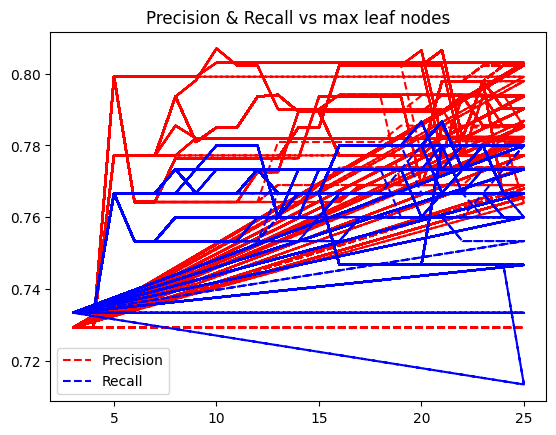

In [19]:
y_precision = PerfData['Precision']
y_recall = PerfData['Recall']
y_f1Score = PerfData['F1-Score']
x = PerfData['Max Leaf Nodes']

plt.plot(x, y_precision, 'r--', label='Precision')
plt.plot(x, y_recall, 'b--', label='Recall')
plt.legend()
plt.title('Precision & Recall vs max leaf nodes')
best_mln = x[y_f1Score.idxmax()]
print(f"max leap nodes with highest F1-Score: {best_mln}")
print(f"Best F1-score: {max(PerfData['F1-Score'])}")

Observations:-

Best F1-score 79.16% occured when maximum no. of leaf nodes was 20.
Precision and Recall are fairly balanced.

max tree depth with highest F1-Score: 7


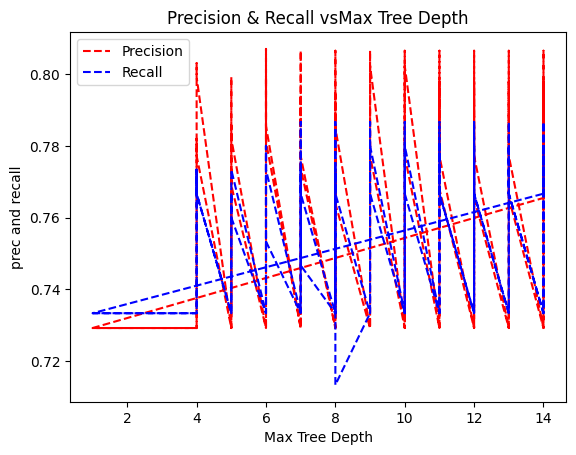

In [20]:
y_precision = PerfData['Precision']
y_recall = PerfData['Recall']
y_f1Score = PerfData['F1-Score']
x = PerfData['Max Tree Depth']

plt.plot(x, y_precision, 'r--', label='Precision')
plt.plot(x, y_recall, 'b--', label='Recall')

plt.xlabel('Max Tree Depth')
plt.ylabel('prec and recall')
plt.legend()
plt.title('Precision & Recall vsMax Tree Depth')
best_mtd = x[y_f1Score.idxmax()]
print(f"max tree depth with highest F1-Score: {best_mtd}")

Observations:-

Best F1-score occurs at max tree depth: 7
Both Precision and Recall show considerable variation.
Precision is generally higher than recall in most of the depth values.
Recall attains its minimum value at max depth of 8